# Transaction Foundation Model on Ray — Part 6: Downstream fraud — raw vs FM vs fusion

<div align="left">
  <a target="_blank" href="https://console.anyscale.com/template-preview/fintech_transaction_fm"><img src="https://img.shields.io/badge/🚀 Run_on-Anyscale-9hf"></a>&nbsp;
  <a href="https://github.com/anyscale/templates/tree/main/templates/fintech_transaction_fm" role="button"><img src="https://img.shields.io/static/v1?label=&message=View%20On%20GitHub&color=586069&logo=github&labelColor=2f363d"></a>&nbsp;
</div>

**⏱️ Time to complete**: ~10 min

---

This is the payoff of the whole series: does the foundation-model embedding actually help catch fraud, compared to the features a team already has? We answer it with a controlled experiment. At `small`/`full` the embedding table is millions of rows by hundreds of dimensions — too big to pull onto one node and fit in-process — so the classifier itself trains on the cluster: Ray Data streams the embeddings and `XGBoostTrainer` distributes the boosting across workers (CPU here at `mini`, GPUs at `small`/`full`). It's the same `ScalingConfig` knob the pretrain and embed stages turn.


In [1]:
import sys, os, json, logging

DEMO_ROOT = os.path.abspath(os.getcwd())
if DEMO_ROOT not in sys.path:
    sys.path.insert(0, DEMO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ray

from src.paths import artifact_paths, get_demo_base_dir
from src.scale_config import load_scale

SCALE = "full"                       # same knob as the earlier parts
paths = artifact_paths(get_demo_base_dir(), SCALE)

# How this scale fits the classifier: mini = 1 CPU worker (reproducible, CI-safe);
# small/full = GPU workers. Same code path either way.
ds_cfg = load_scale(SCALE)["downstream"]
NUM_WORKERS, USE_GPU = ds_cfg["num_workers"], ds_cfg["use_gpu"]

# XGBoost reports a metric every boosting round; keep that out of the notebook.
for _n in ("ray.data", "ray.train", "ray.tune"):
    logging.getLogger(_n).setLevel(logging.ERROR)
ray.data.DataContext.get_current().enable_progress_bars = False

## Does the embedding beat the features you already have?

We train the **same XGBoost** on three feature sets, so the only thing that changes is the *representation*:

1. **raw** — the target transaction's own fields: NVIDIA's 13-column baseline (amount, hour, date, MCC, channel/use-chip, merchant, city, state, zip, card identity), ordinal-encoded. This is the strong hand-built baseline a fraud team has today — the FM has to beat *this*, not a toy 4-field version.
2. **fm** — only the FM embedding of the card's history window, with none of the raw fields.
3. **fusion** — the embedding concatenated with the raw fields (Nubank's joint-fusion recipe).

The lift of **fm** and **fusion** over **raw** is the case for a transaction foundation model: it says you can drop or augment a hand-tuned feature pipeline with one pretrained encoder.

The evaluation follows NVIDIA's transaction-FM blueprint so the numbers are comparable: the **temporal 80/10/10 split** from Part 2 (train on the past, test on the most recent 10% — no leakage), per-transaction last-event labels, and **PR-AUC at natural fraud prevalence** (the downsampled normals are importance-weighted back to ~0.1%). An eval fingerprint makes two runs comparable only if they scored the exact same held-out set.

## Fit all three on the cluster

`XGBoostTrainer` is the lesson here. Ray Data reads the embedding Parquet and `expand_features` fans the single `embedding` column out to `emb_0 .. emb_{d-1}` — XGBoost needs a flat numeric matrix — applying the same log-amount transform the raw baseline uses. It runs as a `map_batches`, so the fan-out is distributed and the driver never holds the whole table. Each feature set is then just a **column subset** of that one expanded dataset.

The fit distributes through a single `ScalingConfig`: Ray shards the training rows across workers, each worker builds a `DMatrix` from its shard, and XGBoost's collective runs the boosting. Going from this CPU smoke test to a multi-GPU fit is `num_workers`/`use_gpu` — no code change. Scoring scales the same way: at `full` the held-out split is millions of rows by hundreds of dims (`holdout_keep=1.0` scores every holdout transaction for exact full-population metrics), so it's scored with a distributed `map_batches` and only the thin `(proba, label, weight)` columns return to the driver — never the wide feature matrix.


In [2]:
from ray.train import RunConfig, ScalingConfig
from ray.train.xgboost import RayTrainReportCallback, XGBoostTrainer
from src.downstream import expand_features, feature_columns, xgb_params, train_loop_per_worker, evaluate
import time

# Distributed read + fan-out, materialized ONCE. Without the trailing
# .materialize() the read + expand_features would re-run for every split below
# (3x the Parquet I/O and fan-out at `full`); materializing makes the per-split
# filter() a cheap scan of the in-memory blocks instead. filter() carves out the
# temporal splits Part 2 cut.
ds = ray.data.read_parquet(paths["embeddings"]).map_batches(expand_features, batch_format="pandas").materialize()
splits = {s: ds.filter(expr=f"split == '{s}'").materialize() for s in ("train", "val", "test")}

# scale_pos_weight (fraud is rare). Only the tiny label/weight columns come to the
# driver for the class-balance stat — at `full` the test split is millions of rows
# by hundreds of dims (holdout_keep=1.0 scores every holdout normal), so it stays a
# distributed dataset and is scored on the cluster below; pulling it to the driver
# would OOM the kernel.
meta = splits["train"].select_columns(["label", "weight"]).to_pandas()
pos = float(meta["label"].sum())
spw = (len(meta) - pos) / max(pos, 1.0)
n_test = splits["test"].count()
all_cols = ds.schema().names
print(f"[downstream] loaded  train={len(meta):,}  val={splits['val'].count():,}  test={n_test:,}  (emb_dim={len(feature_columns('fm', all_cols))})")

# THE scale knob: 1 CPU worker here, GPU workers at small/full — same code below.
scaling = ScalingConfig(num_workers=NUM_WORKERS, use_gpu=USE_GPU)
# Ray Train persists each fit's checkpoint here; shared storage so any node can read it.
storage = os.path.join(os.path.abspath(paths["downstream"]), "ray_results")
os.makedirs(storage, exist_ok=True)

results, preds = {}, []
for name in ["raw", "fm", "fusion"]:
    cols = feature_columns(name, all_cols)               # raw=NVIDIA's 13-col set, fm=embedding, fusion=both
    print(f"[downstream] training '{name}'  ({len(cols)} features, num_workers={NUM_WORKERS}, use_gpu={USE_GPU}) ...", flush=True)
    t0 = time.time()
    trainer = XGBoostTrainer(
        train_loop_per_worker=train_loop_per_worker,
        train_loop_config={
            "label_column": "label",
            "params": xgb_params(spw, USE_GPU),          # one recipe, shared across all three
            "num_boost_round": 400,
            "early_stopping_rounds": 30,
        },
        scaling_config=scaling,
        run_config=RunConfig(name=f"downstream_{name}", storage_path=storage),
        datasets={
            "train": splits["train"].select_columns(cols + ["label"]),
            "valid": splits["val"].select_columns(cols + ["label"]),
        },
    )
    booster = RayTrainReportCallback.get_model(trainer.fit().checkpoint)
    # Distributed scoring: the test split is scored on the cluster and only the
    # thin (proba, label, weight) rows return to the driver.
    results[name], scored = evaluate(splits["test"], cols, booster)
    print(f"[downstream]   '{name}' done in {time.time() - t0:>4.0f}s  "
          f"AUC-ROC={results[name]['auc_roc']:.4f}  PR-AUC={results[name]['pr_auc']:.4f}", flush=True)
    scored["feature_set"] = name
    preds.append(scored)
pred = pd.concat(preds, ignore_index=True)

2026-07-02 20:22:27,328	INFO worker.py:1814 -- Connecting to existing Ray cluster at address: 10.0.119.117:6379...
2026-07-02 20:22:27,361	INFO worker.py:2003 -- Connected to Ray cluster. View the dashboard at https://session-nridlis6nyy2hi9qv4il5lcj6q.i.anyscaleuserdata.com 
2026-07-02 20:22:27,407	INFO packaging.py:463 -- Pushing file package 'gcs://_ray_pkg_1333f07d7c06129ae7cbbb465c21402fd2453b4a.zip' (16.45MiB) to Ray cluster...
2026-07-02 20:22:27,474	INFO packaging.py:476 -- Successfully pushed file package 'gcs://_ray_pkg_1333f07d7c06129ae7cbbb465c21402fd2453b4a.zip'.
/home/ray/anaconda3/lib/python3.12/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(
2026-07-02 20:22:27,956	INFO logging.py:416 -- Registered dataset logge

[downstream] loaded  train=321,077  val=2,438,693  test=2,438,690  (emb_dim=512)
[downstream] training 'raw'  (14 features, num_workers=16, use_gpu=True) ...


(TrainController pid=287721) Requesting resources: {'GPU': 1} * 16
(TrainController pid=287721) [State Transition] INITIALIZING -> SCHEDULING.
(TrainController pid=287721) Attempting to start training worker group of size 16 with the following resources: [{'GPU': 1}] * 16
(TrainController pid=287721) Started training worker group of size 16: 
(TrainController pid=287721) - (ip=10.0.122.23, pid=14668) world_rank=0, local_rank=0, node_rank=0
(TrainController pid=287721) - (ip=10.0.95.254, pid=13870) world_rank=1, local_rank=0, node_rank=1
(TrainController pid=287721) - (ip=10.0.76.36, pid=10958) world_rank=2, local_rank=0, node_rank=2
(TrainController pid=287721) - (ip=10.0.81.251, pid=14149) world_rank=3, local_rank=0, node_rank=3
(TrainController pid=287721) - (ip=10.0.65.156, pid=12208) world_rank=4, local_rank=0, node_rank=4
(TrainController pid=287721) - (ip=10.0.101.55, pid=14795) world_rank=5, local_rank=0, node_rank=5
(TrainController pid=287721) - (ip=10.0.105.85, pid=11167) wor

(raylet) WARNING: 4 PYTHON worker processes have been started on node: 23a9ae72724cabd424b2167979405593c2032b97190e29f57e78b7f7 with address: 10.0.119.117, which is 4x the maximum expected startup concurrency (1). This could be a result of using a large number of actors, tasks blocked in ray.get() calls, or tasks with fractional CPU requests (e.g., num_cpus=0.1) allowing high concurrency. See https://github.com/ray-project/ray/issues/3644 for some discussion of workarounds.


(SplitCoordinator pid=288291) Starting execution of Dataset valid_450_0. Full logs are in /tmp/ray/session_2026-07-02_10-58-50_130263_2811/logs/ray-data
(SplitCoordinator pid=288291) Execution plan of Dataset valid_450_0: InputDataBuffer[Input] -> TaskPoolMapOperator[Project] -> OutputSplitter[split(16, equal=True)]
(SplitCoordinator pid=288291) ✔️  Dataset valid_450_0 execution finished in 1.67 seconds [repeated 17x across cluster]
(SplitCoordinator pid=288291) Registered dataset logger for dataset valid_450_0 [repeated 16x across cluster]
(SplitCoordinator pid=288291) ⚠️  Ray's object store is configured to use only 28.5% of available memory (583.2GiB out of 2048.0GiB total). For optimal Ray Data performance, we recommend setting the object store to at least 50% of available memory. You can do this by setting the 'object_store_memory' parameter when calling ray.init() or by setting the RAY_DEFAULT_OBJECT_STORE_MEMORY_PROPORTION environment variable. [repeated 16x across cluster]
(Spl

...

(autoscaler +3m42s) Tip: use `ray status` to view detailed cluster status. To disable these messages, set RAY_SCHEDULER_EVENTS=0.


(TrainController pid=289233) [20:26:57] [50]	train-aucpr:0.57093	valid-aucpr:0.00543
(RayTrainWorker pid=15607, ip=10.0.81.251) Checkpoint successfully created at: Checkpoint(filesystem=local, path=/mnt/cluster_storage/transaction-fm/downstream/full/ray_results/downstream_fm/checkpoint_2026-07-02_20-28-07.494812)
(TrainController pid=289233) [20:28:09] [85]	train-aucpr:0.63705	valid-aucpr:0.00577
(TrainController pid=289233) [State Transition] RUNNING -> SHUTTING_DOWN.
2026-07-02 20:28:14,425	INFO logging.py:416 -- Registered dataset logger for dataset dataset_507_0
2026-07-02 20:28:14,435	INFO streaming_executor.py:166 -- Starting execution of Dataset dataset_507_0. Full logs are in /tmp/ray/session_2026-07-02_10-58-50_130263_2811/logs/ray-data
2026-07-02 20:28:14,436	INFO streaming_executor.py:167 -- Execution plan of Dataset dataset_507_0: InputDataBuffer[Input] -> TaskPoolMapOperator[MapBatches(_score)]
(TrainController pid=289233) [State Transition] SHUTTING_DOWN -> FINISHED.
2026

[downstream]   'fm' done in  231s  AUC-ROC=0.8222  PR-AUC=0.0069
[downstream] training 'fusion'  (526 features, num_workers=16, use_gpu=True) ...


(TrainController pid=291570) Requesting resources: {'GPU': 1} * 16
(TrainController pid=291570) [State Transition] INITIALIZING -> SCHEDULING.
(TrainController pid=291570) Attempting to start training worker group of size 16 with the following resources: [{'GPU': 1}] * 16
(TrainController pid=291570) Started training worker group of size 16: 
(TrainController pid=291570) - (ip=10.0.71.101, pid=18052) world_rank=0, local_rank=0, node_rank=0
(TrainController pid=291570) - (ip=10.0.64.211, pid=17390) world_rank=1, local_rank=0, node_rank=1
(TrainController pid=291570) - (ip=10.0.95.254, pid=17591) world_rank=2, local_rank=0, node_rank=2
(TrainController pid=291570) - (ip=10.0.122.23, pid=18712) world_rank=3, local_rank=0, node_rank=3
(TrainController pid=291570) - (ip=10.0.81.251, pid=17886) world_rank=4, local_rank=0, node_rank=4
(TrainController pid=291570) - (ip=10.0.65.156, pid=14819) world_rank=5, local_rank=0, node_rank=5
(TrainController pid=291570) - (ip=10.0.101.55, pid=18530) wo

[downstream]   'fusion' done in  145s  AUC-ROC=0.9236  PR-AUC=0.0149


In [3]:
def _lift(k):
    return results[k]["pr_auc"] - results["raw"]["pr_auc"]

# All three feature sets scored the same held-out rows; use one for the prevalence stat.
_t = pred[pred["feature_set"] == "raw"]
print(f"trained distributed: num_workers={NUM_WORKERS} use_gpu={USE_GPU}")
print(f"test samples: {len(_t):,}  (natural fraud rate "
      f"{(_t['weight'] * _t['label']).sum() / _t['weight'].sum():.4%})")
print(f"{'feature set':<10}{'AUC-ROC':>10}{'PR-AUC':>10}")
print("-" * 30)
for name in ["raw", "fm", "fusion"]:
    r = results[name]
    print(f"{name:<10}{r['auc_roc']:>10.4f}{r['pr_auc']:>10.4f}")
print("-" * 30)
print(f"FM-only PR-AUC lift vs raw:  {_lift('fm'):+.4f}")
print(f"Fusion PR-AUC lift vs raw:   {_lift('fusion'):+.4f}")

trained distributed: num_workers=16 use_gpu=True
test samples: 2,438,690  (natural fraud rate 0.1115%)
feature set   AUC-ROC    PR-AUC
------------------------------
raw           0.8736    0.0169
fm            0.8222    0.0069
fusion        0.9236    0.0149
------------------------------
FM-only PR-AUC lift vs raw:  -0.0100
Fusion PR-AUC lift vs raw:   -0.0020


## Reading this honestly at `mini` scale

At `mini` the foundation model trailed the raw baseline — and that's the expected, honest result, not a bug. The encoder here was pretrained for **2 CPU epochs at 64 dimensions, 2 layers**: it has barely learned, so a 64-dim summary of recent history can't yet compete with the target transaction's own raw fields. So `mini` is a smoke test of the *pipeline and the evaluation harness*, not a model you'd ship.

What transfers regardless of scale is the **methodology**: a leakage-free temporal split, metrics reported at the true ~0.1% prevalence (where the published TFMs are measured), and a controlled comparison where representation is the only variable. Run the `small`/`full` GPU pretrain and the picture inverts — `fm` and `fusion` overtake `raw`, matching the lift NVIDIA's blueprint and FATA-Trans report on this dataset. The point of this notebook is the apparatus that will *show* that lift, run honestly at a scale that fits on a CPU.

## The curves

Two views of the same held-out scores, both at natural prevalence. **ROC** shows how well each representation *ranks* fraud above normal — readable here because the `mini` model is weak (at `full` a strong model pushes AUC-ROC toward 1.0, where it saturates and hides differences). **Precision–Recall** shows the operational reality: at ~0.1% fraud, precision collapses, which is exactly why PR-AUC — not accuracy or ROC — is the number a fraud team actually optimizes.

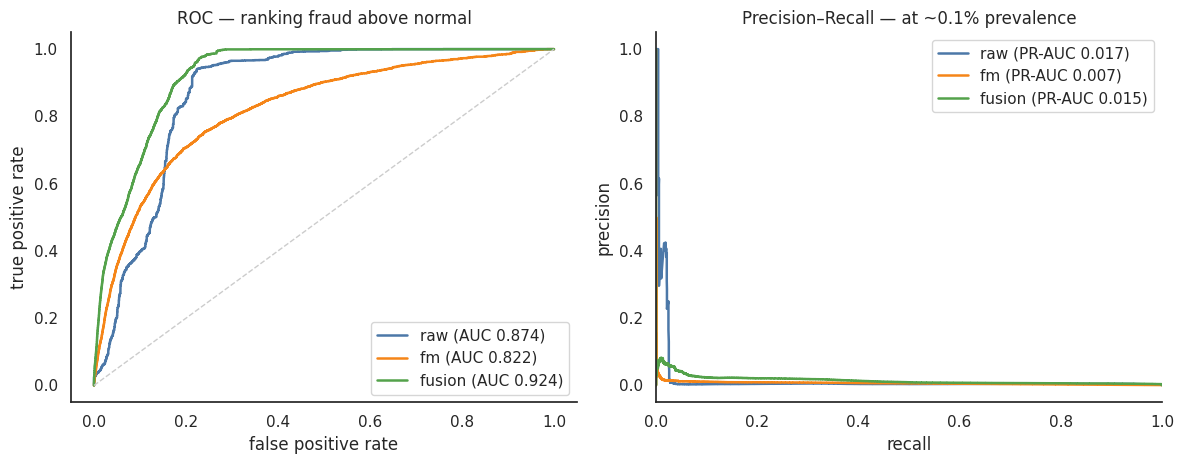

In [4]:
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, average_precision_score

# `pred` was assembled in the training cell above (one row per test sample per
# feature set) — no Parquet round-trip needed inside the notebook.
sns.set_theme(style="white", context="notebook")
COLORS = {"raw": "#4C78A8", "fm": "#F58518", "fusion": "#54A24B"}

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 4.8))
for fs in ["raw", "fm", "fusion"]:
    d = pred[pred["feature_set"] == fs]
    fpr, tpr, _ = roc_curve(d["label"], d["proba"], sample_weight=d["weight"])
    auc = roc_auc_score(d["label"], d["proba"], sample_weight=d["weight"])
    ax_roc.plot(fpr, tpr, color=COLORS[fs], lw=1.8, label=f"{fs} (AUC {auc:.3f})")
    prec, rec, _ = precision_recall_curve(d["label"], d["proba"], sample_weight=d["weight"])
    ap = average_precision_score(d["label"], d["proba"], sample_weight=d["weight"])
    ax_pr.plot(rec, prec, color=COLORS[fs], lw=1.8, label=f"{fs} (PR-AUC {ap:.3f})")

ax_roc.plot([0, 1], [0, 1], ls="--", color="#cccccc", lw=1)
ax_roc.set_title("ROC — ranking fraud above normal")
ax_roc.set_xlabel("false positive rate"); ax_roc.set_ylabel("true positive rate"); ax_roc.legend()
ax_pr.set_title("Precision–Recall — at ~0.1% prevalence")
ax_pr.set_xlabel("recall"); ax_pr.set_ylabel("precision"); ax_pr.set_xlim(0, 1); ax_pr.legend()
for ax in (ax_roc, ax_pr):
    sns.despine(ax=ax)
plt.tight_layout()
plt.show()

## Takeaways

- **It scales by config, not by rewrite.** The same `read_parquet → map_batches → XGBoostTrainer` code fits on one CPU worker at `mini` and on `num_workers` GPU workers at `small`/`full` — only `ScalingConfig` changes. Pulling millions of embeddings onto one node and fitting in-process was the bottleneck this stage removes; Ray Data shards the read and the training so the driver never holds the full matrix.
- **The comparison is controlled**: one XGBoost recipe, three feature sets, representation the only variable — so any lift is attributable to the embedding, not to tuning.
- **The protocol is honest and comparable**: temporal split (no leakage), per-transaction labels, PR-AUC at the true ~0.1% prevalence, and an eval fingerprint so two runs are only compared when they scored the same held-out set. It matches NVIDIA's transaction-FM blueprint. (Distributed boosting partitions the data across workers, so exact metric values are reproducible for a given worker count, not bit-identical across counts.)
- **At `mini` the FM trails raw** — a 2-epoch, 64-dim CPU encoder is undertrained. The value of this stage is the apparatus; the lift shows up with the `small`/`full` GPU pretrain, where pretrained TFMs beat hand-built features on this benchmark.

---

## Next

**Part 7 — Online serving with Ray Serve**: deploy the encoder behind an HTTP endpoint that returns an embedding and a fraud score in one call, caching the static card-level fields and autoscaling replicas under load.
